# Words and Tokens (Deep Dive) 

**Source**: Jurafsky & Martin, Speech and Language Processing (3rd ed)

This notebook is an interactive guide through the building blocks of NLP. We will go beyond definitions and implement core algorithms from scratch, visualize linguistic laws, and solve practical text processing challenges.

## Learning Objectives
1.  Master text normalization (Tokenization, Stemming, Lemmatization).
2.  Understand the "Unknown Word" problem and Subword Tokenization (BPE).
3.  Write complex Regular Expressions for information extraction.
4.  Implement Minimum Edit Distance with Backtrace for error correction.
5.  Analyze text corpora using Zipf's Law and Heaps' Law.

## Table of Contents
1. [Words types and tokens](#1.-Words)
2. [Morphemes: Parts of Words](#2.-Morphemes:-Parts-of-Words)
3. [Unicode and Normalization](#3.-Unicode)
4. [Subword Tokenization (BPE)](#4.-Subword-Tokenization:-Byte-Pair-Encoding)
5. [Corpora and Zipf's Law](#5.-Corpora)
6. [Regular Expressions Workshop](#6.-Regular-Expressions)
7. [Simple Unix Tools](#7.-Simple-Unix-Tools-for-Word-Tokenization)
8. [Rule-based tokenization](#8.-Rule-based-tokenization)
9. [Minimum Edit Distance with Backtrace](#9.-Minimum-Edit-Distance)

In [1]:
# Universal Setup
!pip install nltk spacy numpy matplotlib pandas
!python -m spacy download en_core_web_sm

import nltk
import spacy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('gutenberg')
nltk.download('stopwords')


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rajaramkankipati/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rajaramkankipati/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/rajaramkankipati/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/rajaramkankipati/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rajaramkankipati/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Words

### Types vs. Tokens
*   **Token**: An instance of a sequence of characters in some particular document.
*   **Type**: The class of all same tokens (an entry in the vocabulary).

**Example**:
> "rose is a rose is a rose"

Count the tokens and types below.

In [2]:
sentence = "rose is a rose is a rose"
tokens = sentence.split()
types = set(tokens)

print(f"Sentence: {sentence}")
print(f"Number of Tokens (N): {len(tokens)}")
print(f"Number of Types (V): {len(types)}")
print(f"Values of Types: {types}")

# Type-Token Ratio (TTR)
ttr = len(types) / len(tokens)
print(f"Type-Token Ratio (TTR): {ttr:.2f}")

Sentence: rose is a rose is a rose
Number of Tokens (N): 7
Number of Types (V): 3
Values of Types: {'is', 'rose', 'a'}
Type-Token Ratio (TTR): 0.43


### Your Turn 🧠
Calculate the TTR for the following paragraph. Is it higher or lower than the sentence above? Why?

In [3]:
paragraph = """
Natural language processing (NLP) is a subfield of linguistics, computer science, and artificial intelligence 
concerned with the interactions between computers and human language, in particular how to program computers 
to process and analyze large amounts of natural language data.
"""
# Your code here
p_tokens = paragraph.lower().split()
# ...


## 2. Morphemes: Parts of Words

Words typically have internal structure:
**Stems**: The main morpheme yielding the word's primary meaning.
**Affixes**: Additional morphemes that modify the meaning.

| Type | Function | Examples | Class Change? |
| :--- | :--- | :--- | :--- |
| **Inflectional** | Grammatical function | -s, -ed, -ing | No |
| **Derivational** | Creates new words | -tion, -ize, -ly, un- | Often Yes |


In [4]:
# Manual Identification Exercise
words = ["unbreakable", "running", "civilization", "cats"]

# Can you split these into Stem + Affixes?
# unbreakable -> un- (derivational) + break (stem) + -able (derivational)
# running -> run (stem) + -ning (inflectional, doubling n)


## 3. Unicode

Text is just a sequence of bytes. To give it meaning, we map bytes to characters using **Unicode**.
A common pitfall is **Normalization**: The same character can be represented in multiple ways.

*   **NFC** (Normalization Form C): Composition (Canonical Decomposition, followed by Canonical Composition).
*   **NFD** (Normalization Form D): Decomposition (Canonical Decomposition).

In [5]:
import unicodedata

c1 = "café"
c2 = "cafe\u0301" # cafe + combining acute accent

print(f"c1: {c1}, length: {len(c1)}")
print(f"c2: {c2}, length: {len(c2)}")
print(f"Are they equal? {c1 == c2}")

# Solution: Normalize
n1 = unicodedata.normalize('NFC', c1)
n2 = unicodedata.normalize('NFC', c2)
print(f"Are they equal after NFC normalization? {n1 == n2}")

c1: café, length: 4
c2: café, length: 5
Are they equal? False
Are they equal after NFC normalization? True


## 4. Subword Tokenization: Byte-Pair Encoding

Traditional word tokenization fails on "Unknown Words" (OOV). Modern models (BERT, GPT) use **Subword Tokenization** to break unknown words into known pieces.

**Byte-Pair Encoding (BPE)** is an iterative algorithm:
1.  Init vocabulary with all characters.
2.  Count frequent adjacent symbol pairs (bigrams).
3.  Merge the most frequent pair into a new symbol.
4.  Repeat.

In [6]:
# Educational BPE Implementation
import re, collections

def get_stats(vocab):
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pairs[symbols[i],symbols[i+1]] += freq
    return pairs

def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

# Initial Corpus (word frequencies)
vocab = {
    'l o w </w>': 5, 
    'l o w e r </w>': 2, 
    'n e w e s t </w>': 6, 
    'w i d e s t </w>': 3
}
num_merges = 8

print("--- Starting BPE Merges ---")
for i in range(num_merges):
    pairs = get_stats(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    print(f"Iter {i+1}: Merged {best} -> Current Vocab Size: {len(pairs)}")

print("\nFinal Tokenized Vocabulary:")
for k, v in vocab.items():
    print(f"{k}: {v}")

--- Starting BPE Merges ---
Iter 1: Merged ('e', 's') -> Current Vocab Size: 14
Iter 2: Merged ('es', 't') -> Current Vocab Size: 14
Iter 3: Merged ('est', '</w>') -> Current Vocab Size: 13
Iter 4: Merged ('l', 'o') -> Current Vocab Size: 12
Iter 5: Merged ('lo', 'w') -> Current Vocab Size: 11
Iter 6: Merged ('n', 'e') -> Current Vocab Size: 10
Iter 7: Merged ('ne', 'w') -> Current Vocab Size: 9
Iter 8: Merged ('new', 'est</w>') -> Current Vocab Size: 8

Final Tokenized Vocabulary:
low </w>: 5
low e r </w>: 2
newest</w>: 6
w i d est</w>: 3


## 5. Corpora

### Zipf's Law
The product of the frequency of a word ($f$) and its rank ($r$) is approximately constant.
$$ f \times r \approx k $$
Or: The $r$-th most frequent word has frequency proportional to $1/r$.

We will verify this using the **Gutenberg Corpus** (Jane Austen's *Emma*).

Total words: 192427


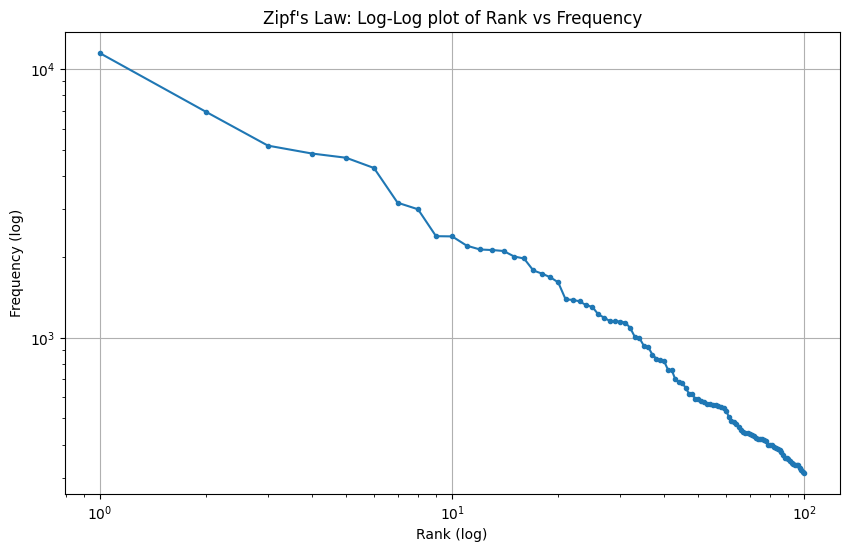

Top 5 words: [(',', 11454), ('.', 6928), ('to', 5183), ('the', 4844), ('and', 4672)]


In [7]:
from nltk.corpus import gutenberg

# Load text
words = gutenberg.words('austen-emma.txt')
print(f"Total words: {len(words)}")

# Calculate frequencies
counts = Counter(words)
most_common = counts.most_common(100)

# Rank vs Frequency
ranks = range(1, len(most_common)+1)
freqs = [freq for word, freq in most_common]

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(ranks, freqs, marker='.')
plt.title("Zipf's Law: Log-Log plot of Rank vs Frequency")
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.grid(True)
plt.show()

print(f"Top 5 words: {most_common[:5]}")

## 6. Regular Expressions

Welcome to the **Regex Dojo**. Solve these challenges to progress.

### Level 1: Find the dates
Format: `dd/mm/yyyy`

In [8]:
text = "The meeting is on 12/05/2024 and the deadline is 30/06/2025."
pattern = r"\d{2}/\d{2}/\d{4}" # <--- Your regex pattern here
matches = re.findall(pattern, text)
print(f"Found: {matches}")

Found: ['12/05/2024', '30/06/2025']


### Level 2: Extract Phone Numbers
Formats: `123-456-7890`, `(123) 456-7890`, `123 456 7890`

In [9]:
text = "Call me at 555-0199 or (123) 456-7890 today."
pattern = r"\(?\d{3}\)?[-\s]\d{3}[-\s]\d{4}" 
matches = re.findall(pattern, text)
print(f"Found: {matches}")

Found: ['(123) 456-7890']


### Level 3: Substitution
Obfuscate all email addresses by replacing them with `[EMAIL]`.

In [10]:
text = "Contact support@openai.com for help."
clean_text = re.sub(r"[\w\.-]+@[\w\.-]+", "[EMAIL]", text)
print(clean_text)

Contact [EMAIL] for help.


## 7. Simple Unix Tools for Word Tokenization

The Unix Philosophy: Small tools that do one thing well, chained by pipes.

Task: **Get the top 5 most frequent words in a text.**
Steps:
1.  `tr`: Translate non-alphas to newlines (tokenize).
2.  `sort`: Sort alphabetically.
3.  `uniq -c`: Count unique occurrences.
4.  `sort -nr`: Sort numerically reverse (descending).
5.  `head -n 5`: Take top 5.

In [11]:
# Write dummy file
text = "The quick brown fox jumps over the lazy dog. The dog barks."
with open('fox.txt', 'w') as f: f.write(text)

# Magic command to run shell
! tr -sc 'A-Za-z' '\n' < fox.txt | sort | uniq -c | sort -nr | head -n 5

   2 dog
   2 The
   1 the
   1 quick
   1 over


## 8. Rule-based tokenization

### NLTK vs spaCy: The Showdown
Let's test them on edge cases: dates, money, and clitics.

In [12]:
sentence = "I didn't pay $5.50 for the U.S.A. trip on 12/05/2024!"

print("--- NLTK ---")
print(nltk.word_tokenize(sentence))

print("\n--- spaCy ---")
nlp = spacy.load("en_core_web_sm")
doc = nlp(sentence)
print([t.text for t in doc])

--- NLTK ---
['I', 'did', "n't", 'pay', '$', '5.50', 'for', 'the', 'U.S.A.', 'trip', 'on', '12/05/2024', '!']

--- spaCy ---
['I', 'did', "n't", 'pay', '$', '5.50', 'for', 'the', 'U.S.A.', 'trip', 'on', '12/05/2024', '!']


## 9. Minimum Edit Distance

We will implement the **Levenshtein Distance** algorithm using Dynamic Programming. 
Crucially, we will add a **backtrace feature** to visualize *how* to transform one string to the other.

In [13]:
def min_edit_distance_backtrace(source, target):
    n = len(source)
    m = len(target)
    
    # Matrix initialization
    D = np.zeros((n+1, m+1), dtype=int)
    for i in range(n+1): D[i, 0] = i
    for j in range(m+1): D[0, j] = j
        
    # DP Calculation
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if source[i-1] == target[j-1] else 2
            D[i, j] = min(
                D[i-1, j] + 1,       # Deletion
                D[i, j-1] + 1,       # Insertion
                D[i-1, j-1] + cost   # Substitution
            )
            
    # Backtrace
    i, j = n, m
    ops = []
    
    while i > 0 or j > 0:
        if i > 0 and j > 0 and source[i-1] == target[j-1]:
            ops.append(f"Keep '{source[i-1]}'")
            i, j = i-1, j-1
        elif i > 0 and j > 0 and D[i, j] == D[i-1, j-1] + 2:
            ops.append(f"Substitute '{source[i-1]}' -> '{target[j-1]}'")
            i, j = i-1, j-1
        elif i > 0 and D[i, j] == D[i-1, j] + 1:
            ops.append(f"Delete '{source[i-1]}'")
            i -= 1
        else:
            ops.append(f"Insert '{target[j-1]}'")
            j -= 1
            
    return D[n, m], ops[::-1], D

source = "intention"
target = "execution"
dist, operations, matrix = min_edit_distance_backtrace(source, target)

print(f"Edit Distance: {dist}")
print("Operations:")
for op in operations:
    print(f" - {op}")

# Visualize Matrix
df_matrix = pd.DataFrame(matrix, index=['#'] + list(source), columns=['#'] + list(target))
df_matrix

Edit Distance: 8
Operations:
 - Delete 'i'
 - Substitute 'n' -> 'e'
 - Substitute 't' -> 'x'
 - Keep 'e'
 - Insert 'c'
 - Substitute 'n' -> 'u'
 - Keep 't'
 - Keep 'i'
 - Keep 'o'
 - Keep 'n'


,#,e,x,e,c,u,t,i,o,n
#,0,1,2,3,4,5,6,7,8,9
i,1,2,3,4,5,6,7,6,7,8
n,2,3,4,5,6,7,8,7,8,7
t,3,4,5,6,7,8,7,8,9,8
e,4,3,4,5,6,7,8,9,10,9
n,5,4,5,6,7,8,9,10,11,10
t,6,5,6,7,8,9,8,9,10,11
i,7,6,7,8,9,10,9,8,9,10
o,8,7,8,9,10,11,10,9,8,9
n,9,8,9,10,11,12,11,10,9,8


### Exploration
Try changing `source` and `target` above to your name and a misspelling of it.
Note how the path finds the optimal set of edits.